In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [35]:
buildings_df = pd.read_csv('../Cleaned_data/buildings_clean.csv')
lights_df = pd.read_csv('../Cleaned_data/lights_clean.csv')
furniture_df = pd.read_csv('../Cleaned_data/street_inf_clean.csv')
bikes_df = pd.read_csv('../Cleaned_data/bikes_clean.csv')
landmarks_df = pd.read_csv('../Cleaned_data/landmarks_clean.csv')

## Buildings
Think she has created a feature which is the average number of floors in the buildings within the sensor's radius

In [140]:
buildings_df.loc[buildings_df["building_use"].isin(["Residential Apartment", 'House/Townhouse', 'Commercial Accommodation',
                                                'Student Accommodation', 'Institutional Accommodation']), "building_use"] = "Residential"
buildings_df.loc[buildings_df["building_use"].str.contains('Unoccupied'), "building_use"] = "Unoccupied"
buildings_df.loc[buildings_df["building_use"].isin(['Retail - Shop', 'Retail - Stall', 'Retail - Showroom', 'Retail - Cars',
                                                'Wholesale']), "building_use"] = "Retail"
buildings_df.loc[buildings_df["building_use"].isin(['Parking - Commercial Covered', 'Parking - Private Covered']),
                 "building_use"] = "Parking"
buildings_df.loc[buildings_df["building_use"].isin(['Workshop/Studio', 'Manufacturing', 'Equipment Installation']),
                 "building_use"] = "Working"                                                   

<AxesSubplot:>

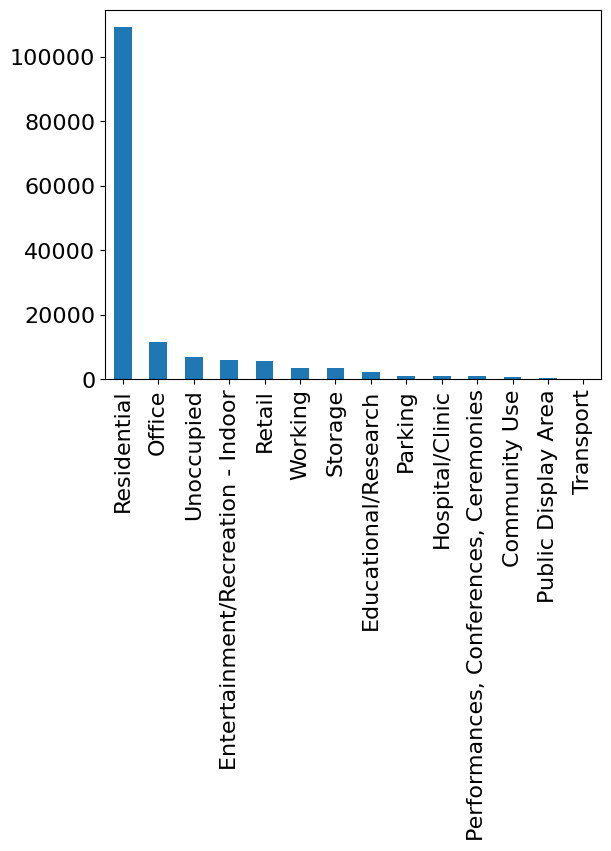

In [141]:
buildings_df['building_use'].value_counts().plot(kind='bar')

## Find which building types are the big ones??

In [153]:
# plt.scatter(buildings_df['building_use'], buildings_df['n_floors'])

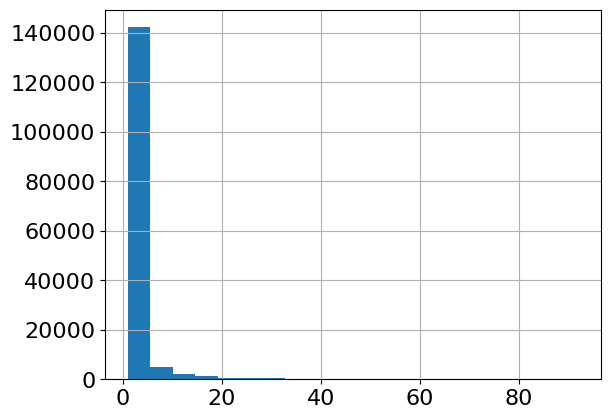

In [160]:
hist = buildings_df['n_floors'].hist(bins=20)

# Checking how much difference there actually is in buildings each year
#### Also, buildings only goes to 2019  - do we assume buildings in subsequent years are the same??

<AxesSubplot:>

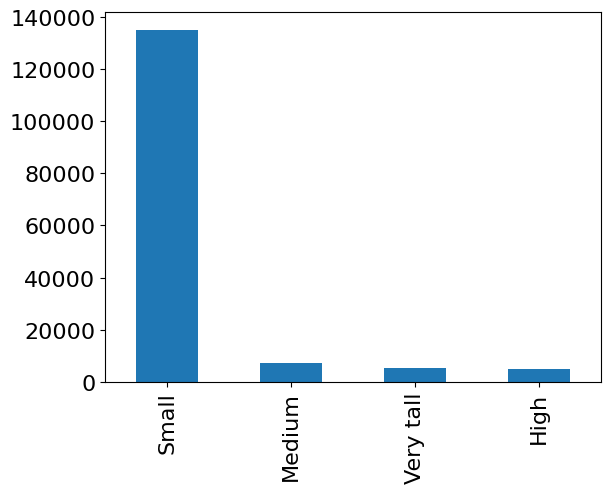

In [170]:
filtered_buildings_df = buildings_df[['building_use', 'n_floors']]
# filtered_buildings_df.groupby(['building_use']).plot(kind='bar')
buildings_df['building_height'] = pd.cut(buildings_df['n_floors'], bins = [0,3,5,10,1000],
                                        labels = ['Small', 'Medium', 'High', 'Very tall'])

# buildings_df.groupby(['building_height']).count()
buildings_df['building_height'].value_counts().plot(kind='bar')

In [ ]:
# Get just the buildings in a dataframe
just_buildings = num_features_near_sensor[['buildings_2011', 'buildings_2012', 'buildings_2013', 'buildings_2014', 'buildings_2015'
,'buildings_2016', 'buildings_2017', 'buildings_2018', 'buildings_2019']].copy()

# Find the maximum difference in the number of buildings near each sensor between the years
just_buildings['MaxDiffInBuildings'] = just_buildings.max(1) - just_buildings.min(1)
# Convert to a proportion of the amximum number of buildings in a year
just_buildings['MaxDiffInBuildings_asprop'] = round(just_buildings['MaxDiffInBuildings']/ just_buildings.max(1) *100,2)
just_buildings.head()

# Check the spread in difference with buildings
just_buildings.hist(column = 'MaxDiffInBuildings_asprop', bins=15)

# Furniture
Most common feature type is bollard - surely we can remove this?
Can remove condition rating variable? Values between 1 and 5

<AxesSubplot:>

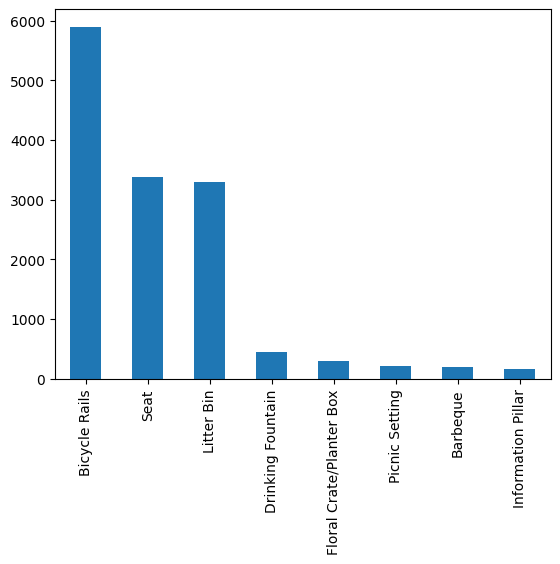

In [32]:
furniture_df['feature'].value_counts().plot(kind='bar')
# Remove the bollards
furniture_df = furniture_df[furniture_df["feature"].isin(['Bollard', 'Tree Guard','Horse Trough', 'Hoop']) == False]
furniture_df['feature'].value_counts().plot(kind='bar')


<AxesSubplot:>

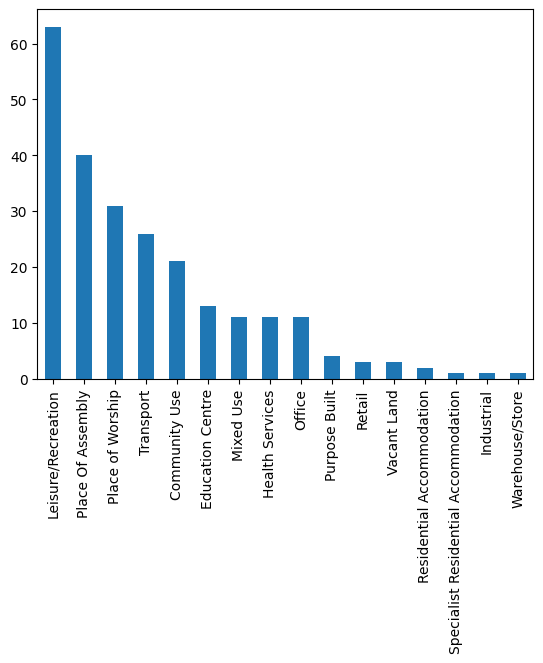

In [41]:
landmarks_df['theme'].value_counts().plot(kind='bar')
# landmarks_df['sub_theme'].value_counts().plot(kind='bar')
# landmarks_df